In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

# Load cleaned dataset
df = pd.read_csv("../data/processed/online_retail_cleaned.csv", parse_dates=["InvoiceDate"])

# Keep only columns needed for RFM
rfm_df = df[["Invoice", "InvoiceDate", "CustomerID", "Revenue"]].copy()

# Quick check
print(rfm_df.shape)
print(rfm_df.head())
print(rfm_df.dtypes)

(805549, 4)
   Invoice         InvoiceDate  CustomerID  Revenue
0   489434 2009-12-01 07:45:00       13085     83.4
1   489434 2009-12-01 07:45:00       13085     81.0
2   489434 2009-12-01 07:45:00       13085     81.0
3   489434 2009-12-01 07:45:00       13085    100.8
4   489434 2009-12-01 07:45:00       13085     30.0
Invoice                 int64
InvoiceDate    datetime64[ns]
CustomerID              int64
Revenue               float64
dtype: object


In [2]:
# Define snapshot date
snapshot_date = rfm_df["InvoiceDate"].max() + pd.Timedelta(days=1)

# Build RFM table
rfm = rfm_df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
    "Invoice": "nunique",
    "Revenue": "sum"
}).reset_index()

# Rename columns
rfm.columns = ["CustomerID", "Recency", "Frequency", "Monetary"]

# Preview
print("Snapshot Date:", snapshot_date)
print(rfm.shape)
rfm.head()

Snapshot Date: 2011-12-10 12:50:00
(5878, 4)


,CustomerID,Recency,Frequency,Monetary
0,12346,326,12,77556.46
1,12347,2,8,5633.32
2,12348,75,5,2019.40
3,12349,19,4,4428.69
4,12350,310,1,334.40


In [3]:
rfm.describe().round(2)


,CustomerID,Recency,Frequency,Monetary
count,5878.00,5878.00,5878.00,5878.00
mean,15315.31,201.33,6.29,3018.62
std,1715.57,209.34,13.01,14737.73
min,12346.00,1.00,1.00,2.95
25%,13833.25,26.00,1.00,348.76
50%,15314.50,96.00,3.00,898.92
75%,16797.75,380.00,7.00,2307.09
max,18287.00,739.00,398.00,608821.65


In [4]:
# Assign RFM scores using quartiles
rfm["R_score"] = pd.qcut(rfm["Recency"], 4, labels=[4, 3, 2, 1]).astype(int)
rfm["F_score"] = pd.qcut(rfm["Frequency"].rank(method="first"), 4, labels=[1, 2, 3, 4]).astype(int)
rfm["M_score"] = pd.qcut(rfm["Monetary"], 4, labels=[1, 2, 3, 4]).astype(int)

# Create combined RFM score
rfm["RFM_score"] = (
    rfm["R_score"].astype(str) +
    rfm["F_score"].astype(str) +
    rfm["M_score"].astype(str)
)

rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score
0,12346,326,12,77556.46,2,4,4,244
1,12347,2,8,5633.32,4,4,4,444
2,12348,75,5,2019.40,3,3,3,333
3,12349,19,4,4428.69,4,3,4,434
4,12350,310,1,334.40,2,1,1,211


In [5]:
rfm[["R_score", "F_score", "M_score"]].apply(pd.Series.value_counts).sort_index()

,R_score,F_score,M_score
1,1459,1470,1470
2,1466,1469,1469
3,1443,1469,1469
4,1510,1470,1470


In [6]:
# Create R and F combined score
rfm["RF_score"] = rfm["R_score"].astype(str) + rfm["F_score"].astype(str)

# Segment customers using RF patterns
seg_map = {
    r'[1-2][1-2]': 'Hibernating',
    r'[1-2][3-4]': 'At Risk',
    r'[3][1-2]': 'About to Sleep',
    r'[3][3]': 'Need Attention',
    r'[3-4][4]': 'Loyal Customers',
    r'[4][1]': 'Promising',
    r'[4][2-3]': 'Potential Loyalists',
    r'[4][4]': 'Champions'
}

rfm["customer_segment"] = rfm["RF_score"].replace(seg_map, regex=True)

rfm[["CustomerID", "Recency", "Frequency", "Monetary", "RF_score", "customer_segment"]].head(10)

,CustomerID,Recency,Frequency,Monetary,RF_score,customer_segment
0,12346,326,12,77556.46,24,At Risk
1,12347,2,8,5633.32,44,Loyal Customers
2,12348,75,5,2019.40,33,Need Attention
3,12349,19,4,4428.69,43,Potential Loyalists
4,12350,310,1,334.40,21,Hibernating
5,12351,375,1,300.93,21,Hibernating
6,12352,36,10,2849.84,34,Loyal Customers
7,12353,204,2,406.76,22,Hibernating
8,12354,232,1,1079.40,21,Hibernating
9,12355,214,2,947.61,22,Hibernating


In [7]:
segment_summary = rfm.groupby("customer_segment").agg(
    customers=("CustomerID", "count"),
    avg_recency=("Recency", "mean"),
    avg_frequency=("Frequency", "mean"),
    avg_monetary=("Monetary", "mean"),
    total_revenue=("Monetary", "sum")
).sort_values("total_revenue", ascending=False).round(2)

segment_summary

,customers,avg_recency,avg_frequency,avg_monetary,total_revenue
customer_segment,,,,,
Loyal Customers,1226,25.97,18.55,9938.18,12184210.85
At Risk,880,277.12,6.53,2524.64,2221679.29
Hibernating,2045,411.56,1.49,555.17,1135329.16
Potential Loyalists,642,13.34,3.78,1585.51,1017898.55
Need Attention,433,56.15,4.56,1773.19,767793.42
About to Sleep,558,56.99,1.70,691.45,385828.79
Promising,94,14.87,1.00,326.48,30689.11


C:\Users\Tyush01\AppData\Local\Temp\ipykernel_24804\2012928673.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


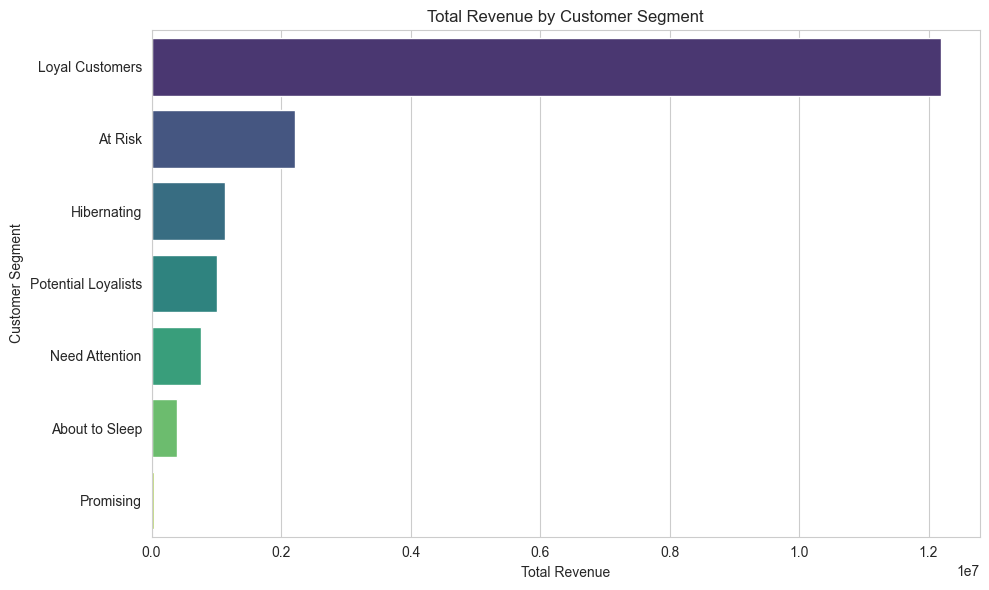

In [8]:
segment_plot = segment_summary.reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(
    data=segment_plot,
    x="total_revenue",
    y="customer_segment",
    palette="viridis"
)
plt.title("Total Revenue by Customer Segment")
plt.xlabel("Total Revenue")
plt.ylabel("Customer Segment")
plt.tight_layout()
plt.show()

C:\Users\Tyush01\AppData\Local\Temp\ipykernel_24804\857553418.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


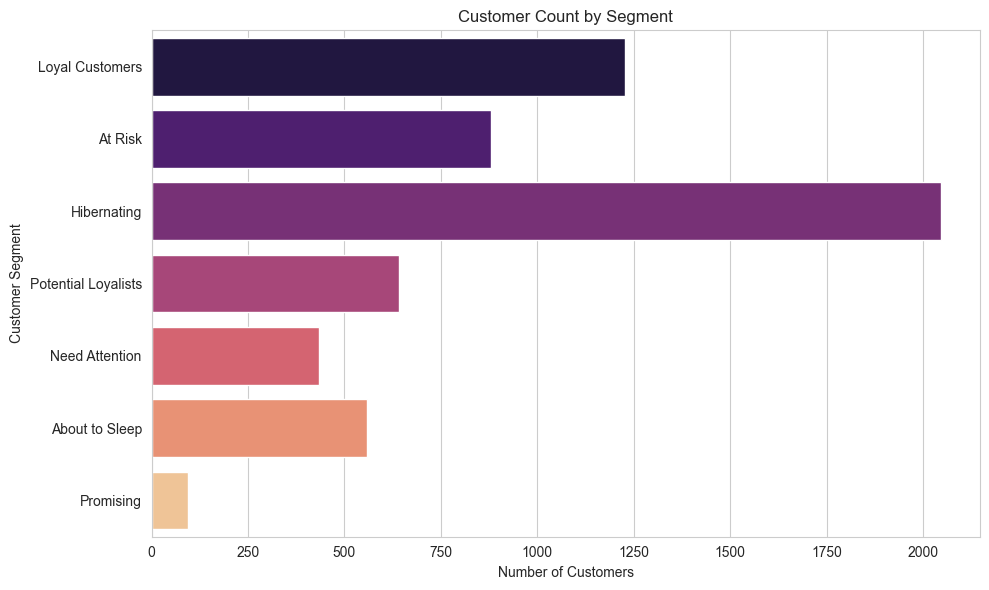

In [9]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=segment_plot,
    x="customers",
    y="customer_segment",
    palette="magma"
)
plt.title("Customer Count by Segment")
plt.xlabel("Number of Customers")
plt.ylabel("Customer Segment")
plt.tight_layout()
plt.show()

In [10]:
rfm.to_csv("../data/processed/rfm_customer_segments.csv", index=False)
segment_summary.to_csv("../data/output/rfm_segment_summary.csv")